# Imports

In [157]:
import numpy as np
import matplotlib.pyplot as plt
from pyod.utils.data import generate_data_clusters
from pyod.models.knn import KNN
from pyod.models.lof import LOF
from sklearn.metrics import balanced_accuracy_score
import warnings
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from pyod.utils.utility import standardizer
from pyod.models.combination import average, maximization
import scipy
warnings.filterwarnings('ignore')

# Ex 1 Leverage scores

In [ ]:
# Methods for generating datasets, computing leverage scores, and plotting (1D + 2D)

def add_bias_column_1d(x):
    # X = [1, x]
    x = np.asarray(x).reshape(-1, 1)
    X = np.hstack([np.ones((x.shape[0], 1)), x])
    return X

def add_bias_columns_2d(x1, x2):
    # X = [1, x1, x2]
    return np.column_stack([np.ones_like(x1), x1, x2])

def leverage_scores(X):
    # H = X (X^T X)^(-1) X^T ; leverage = diag(H)
    XT_X_inv = np.linalg.inv(X.T @ X)
    H = X @ XT_X_inv @ X.T
    return np.diag(H)

def make_1d_dataset(n=200, mu_eps=0.0, sigma_eps=0.2, a=5.0, b=-1.0, rng=None):
    # Regular x near 0 with modest spread
    x_reg = rng.normal(0, 1.0, size=n)

    # Special groups (m points each)
    m = 10
    x_high_var_x = rng.normal(0, 4.0, size=m) # very spread on x (leverage candidates)
    x_high_var_y = rng.normal(0, 1.0, size=m) # normal x
    x_both       = rng.normal(0, 4.0, size=m) # spread on x + y

    # Stack x
    x = np.concatenate([x_reg, x_high_var_x, x_high_var_y, x_both])

    # Noise
    eps_reg        = rng.normal(mu_eps,    sigma_eps,       size=n)   # normal y-noise
    eps_high_var_x = rng.normal(mu_eps,    sigma_eps,       size=m)   # normal y-noise
    eps_high_var_y = rng.normal(mu_eps,    5.0*sigma_eps,   size=m)   # very big y-noise
    eps_both       = rng.normal(mu_eps,    3.0*sigma_eps,   size=m)   # big y-noise

    # Stack noise
    eps = np.concatenate([eps_reg, eps_high_var_x, eps_high_var_y, eps_both])

    # Labels for coloring
    labels = (['regular']*n + ['high_var_x']*m + ['high_var_y']*m + ['both']*m)
    
    # Linear model
    y = a*x + b + eps
    return x, y, np.array(labels)

def make_2d_dataset(n=200, mu_eps=0.0, sigma_eps=0.2, a=2.0, b=-1.5, c=0.5, rng=None):
    # Regular near origin
    x1_reg = rng.normal(0, 1.0, size=n)
    x2_reg = rng.normal(0, 1.0, size=n)

    # Special groups (m points each)
    m = 10
    
    # leverage candidates: far in X-space
    x1_high_var_x = rng.normal(0, 4.0, size=m)
    x2_high_var_x = rng.normal(0, 4.0, size=m)
    # residual outliers: normal X, large noise
    x1_high_var_y = rng.normal(0, 1.0, size=m)
    x2_high_var_y = rng.normal(0, 1.0, size=m)
    # both: spread X + larger noise
    x1_both = rng.normal(0, 4.0, size=m)
    x2_both = rng.normal(0, 4.0, size=m)

    # Stack features
    x1 = np.concatenate([x1_reg, x1_high_var_x, x1_high_var_y, x1_both])
    x2 = np.concatenate([x2_reg, x2_high_var_x, x2_high_var_y, x2_both])

    # Noise
    eps_reg        = rng.normal(mu_eps, sigma_eps,       size=n)
    eps_high_var_x = rng.normal(mu_eps, sigma_eps,       size=m)
    eps_high_var_y = rng.normal(mu_eps, 5.0*sigma_eps,   size=m)
    eps_both       = rng.normal(mu_eps, 3.0*sigma_eps,   size=m)
    
    # Stack noise
    eps = np.concatenate([eps_reg, eps_high_var_x, eps_high_var_y, eps_both])

    labels = np.array(['regular']*n + ['high_var_x']*m + ['high_var_y']*m + ['both']*m)

    y = a*x1 + b*x2 + c + eps
    return x1, x2, y, labels

def plot_1d_on_ax(ax, x, y, labels, topk=10, title='', a=-2.0, b=1.0):
    X = add_bias_column_1d(x)
    lev = leverage_scores(X)
    idx_top = np.argsort(lev)[-topk:] # top-k leverage points
        
    for name, marker in [('regular', 'o'), ('high_var_x', 'o'), ('high_var_y', 'o'), ('both', 'o')]:
        mask = (labels == name)
        ax.scatter(x[mask], y[mask], s=20, marker=marker, alpha=0.7, label=name)
    
    ax.scatter(
    x[idx_top], y[idx_top],
    s=50, facecolors='none', edgecolors='k', linewidths=2,
    label='Top leverage'
    )
    
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = a * x_line + b
    ax.plot(x_line, y_line, 'k--', linewidth=1.5,alpha=0.4, label='True model')
    
    ax.set_title(title + f"\nleverage ≈ {lev.sum():.2f} (should be 2)")
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.legend(fontsize=8, loc='best', frameon=True)

def plot_2d_on_ax(ax, x1, x2, labels, topk=15, title=''):
    X = add_bias_columns_2d(x1, x2)
    lev = leverage_scores(X)
    idx_top = np.argsort(lev)[-topk:] # top-k leverage points

    for name, marker in [('regular', 'o'), ('high_var_x', 'o'), ('high_var_y', 'o'), ('both', 'o')]:
        mask = (labels == name)
        ax.scatter(x1[mask], x2[mask], s=20, marker=marker, alpha=0.7, label=name)

    ax.scatter(x1[idx_top], x2[idx_top], s=50,
               facecolors='none', edgecolors='k', linewidths=2,
               label='Top leverage')

    ax.set_title(title + f"\nleverage ≈ {lev.sum():.2f} (should be 3)")
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.legend(fontsize=8, loc='best', frameon=True)
    

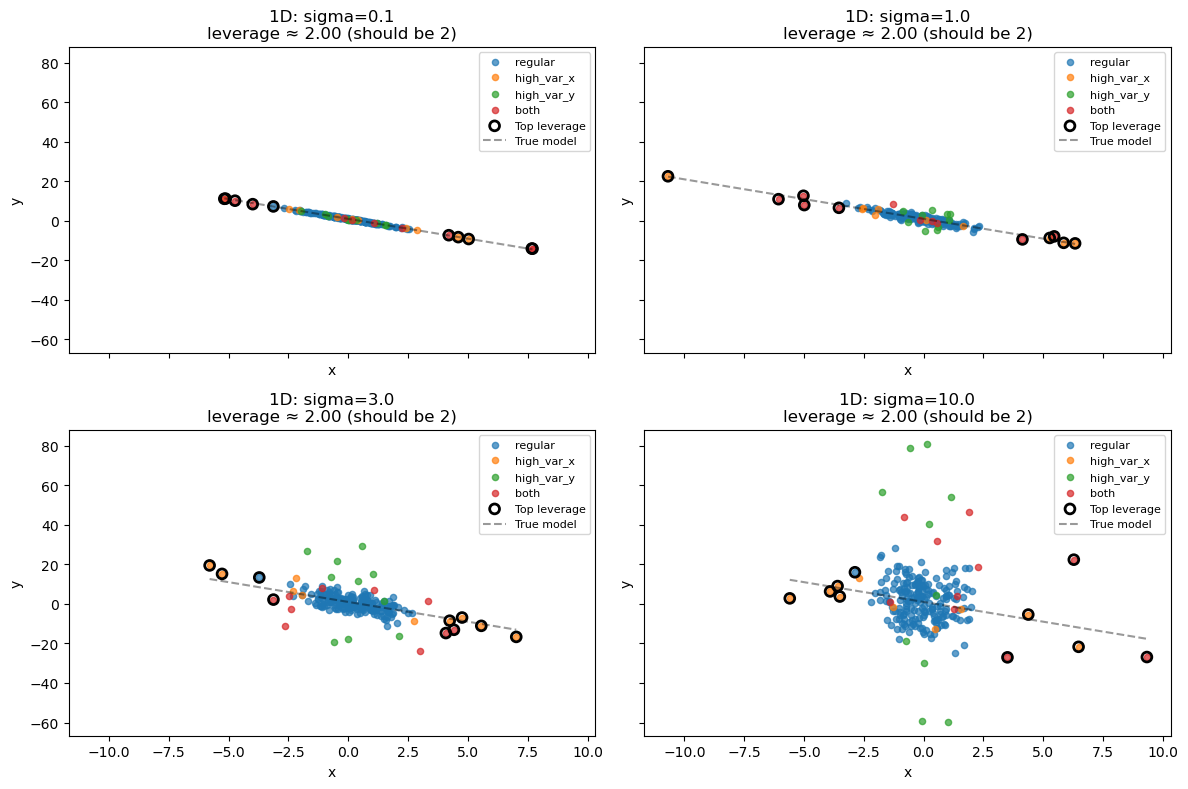

In [93]:
# Model params (1D)
a, b = -2.0, 1.0
rng = np.random.default_rng(28)

sigmas = [0.1, 1.0, 3.0, 10.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, sigma in zip(axes.ravel(), sigmas):
    x, y, labels = make_1d_dataset(n=200, mu_eps=0.0, sigma_eps=sigma, a=a, b=b, rng=rng)
    plot_1d_on_ax(ax, x, y, labels, topk=10, title=f'1D: sigma={sigma}', a=a, b=b)

plt.tight_layout()
plt.show()

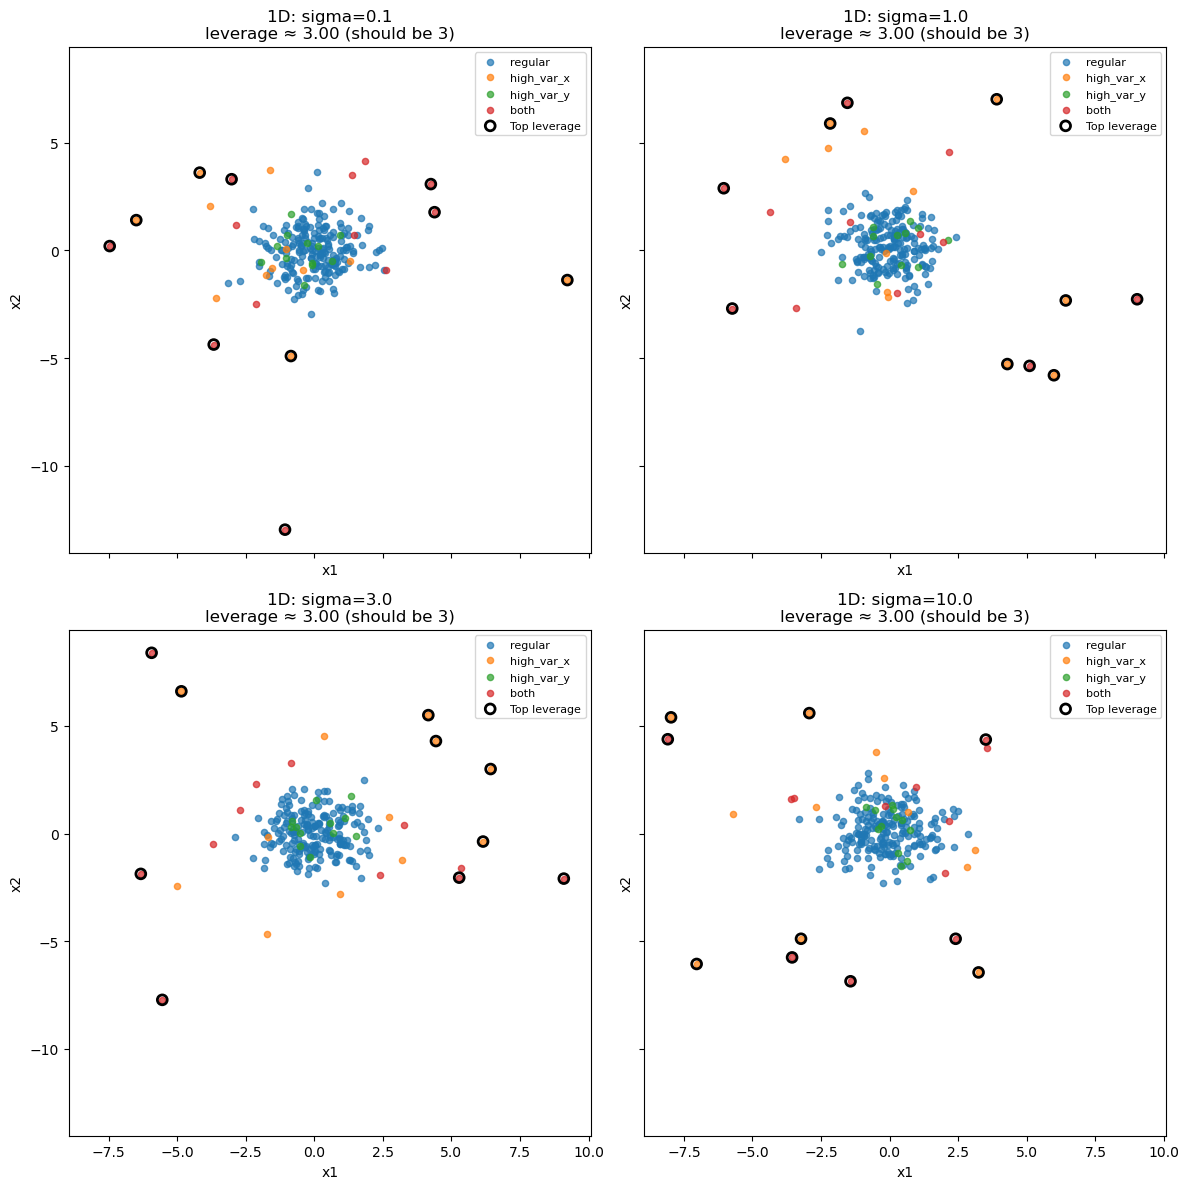

In [90]:
# Model params (2D)
a, b, c = -2.0, 1.5, 0.5
rng = np.random.default_rng(28)

sigmas = [0.1, 1.0, 3.0, 10.0]
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharex=True, sharey=True)
for ax, sigma in zip(axes.ravel(), sigmas):
    x1,x2, y, labels = make_2d_dataset(n=200, mu_eps=0.0, sigma_eps=sigma, a=a, b=b, c=c, rng=rng)
    plot_2d_on_ax(ax, x1, x2, labels, topk=10, title=f'1D: sigma={sigma}')

plt.tight_layout()
plt.show()

# Ex 2 KNN

 Result for K = 1 ==> BA = 0.9415
 Result for K = 3 ==> BA = 0.9887
 Result for K = 5 ==> BA = 0.9944
 Result for K = 7 ==> BA = 0.9915
 Result for K = 10 ==> BA = 0.9915
 Result for K = 15 ==> BA = 0.9944
 Result for K = 20 ==> BA = 0.9859
 Result for K = 25 ==> BA = 0.9859
 Result for K = 30 ==> BA = 0.9887

 Best K = 15 with BA = 0.9944


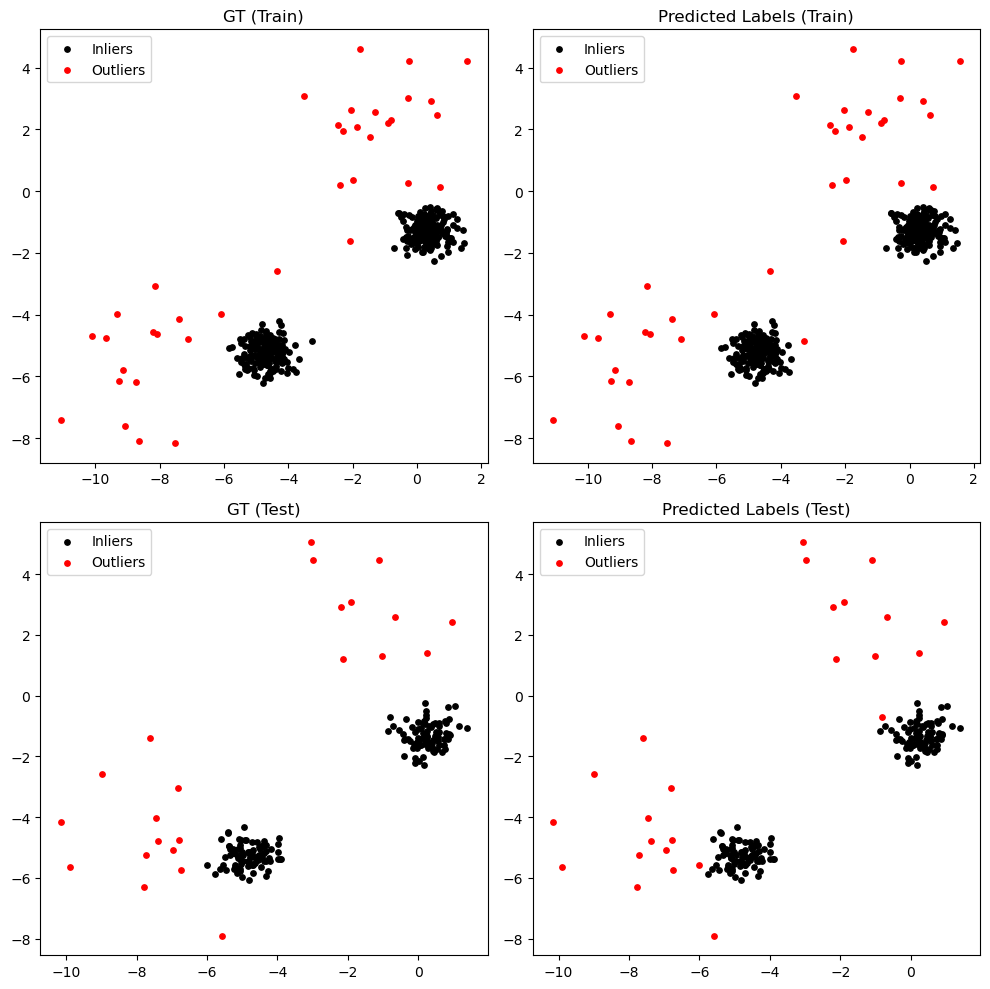

In [118]:
X_train, X_test, y_train, y_test = generate_data_clusters(n_train=400, 
                                                          n_test=200, 
                                                          n_clusters=2,
                                                          n_features=2, 
                                                          contamination=0.1, 
                                                          random_state=28)

k_list = [1, 3, 5, 7, 10, 15, 20, 25, 30]
best_ba = 0.0
best_k = None

for k in k_list:
    model = KNN(contamination=0.1, n_neighbors=k)
    model.fit(X_train)
    y_pred = model.predict(X_test)
    
    ba = balanced_accuracy_score(y_test, y_pred)
    print(f" Result for K = {k} ==> BA = {ba:.4f}")
    
    if ba >= best_ba:
        best_ba = ba
        best_k = k

print(f"\n Best K = {best_k} with BA = {best_ba:.4f}")

model = KNN(contamination=0.1, n_neighbors=best_k)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_pred = model.predict(X_test)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
titles = [
    "GT (Train)",
    "Predicted Labels (Train)",
    "GT (Test)",
    "Predicted Labels (Test)",
]
data_sets = [
    (X_train, y_train),
    (X_train, y_train_pred),
    (X_test, y_test),
    (X_test, y_pred),
]

for ax, (X, y), title in zip(axes.ravel(), data_sets, titles):
    inliers = X[y == 0]
    outliers = X[y == 1]
    ax.scatter(inliers[:, 0], inliers[:, 1], c="black", label="Inliers", s=15)
    ax.scatter(outliers[:, 0], outliers[:, 1], c="red", label="Outliers", s=15)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()


# Ex 3 KNN vs LOF

In [124]:
def fit_predict_models(X, k, contamination):
    knn = KNN(n_neighbors=k, contamination=contamination)
    lof = LOF(n_neighbors=k, contamination=contamination)
    knn.fit(X)
    lof.fit(X)
    y_knn = knn.predict(X)
    y_lof = lof.predict(X)
    return y_knn, y_lof

def plot_predictions(X, y_pred, ax, title):
    inliers = y_pred == 0
    outliers = y_pred == 1

    ax.scatter(X[inliers, 0], X[inliers, 1], s=12, c="blue", label="Inliers")
    ax.scatter(X[outliers, 0], X[outliers, 1], s=28, c="red", label="Outliers")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.legend(frameon=False, loc="best")
    ax.set_aspect("equal", adjustable="box")

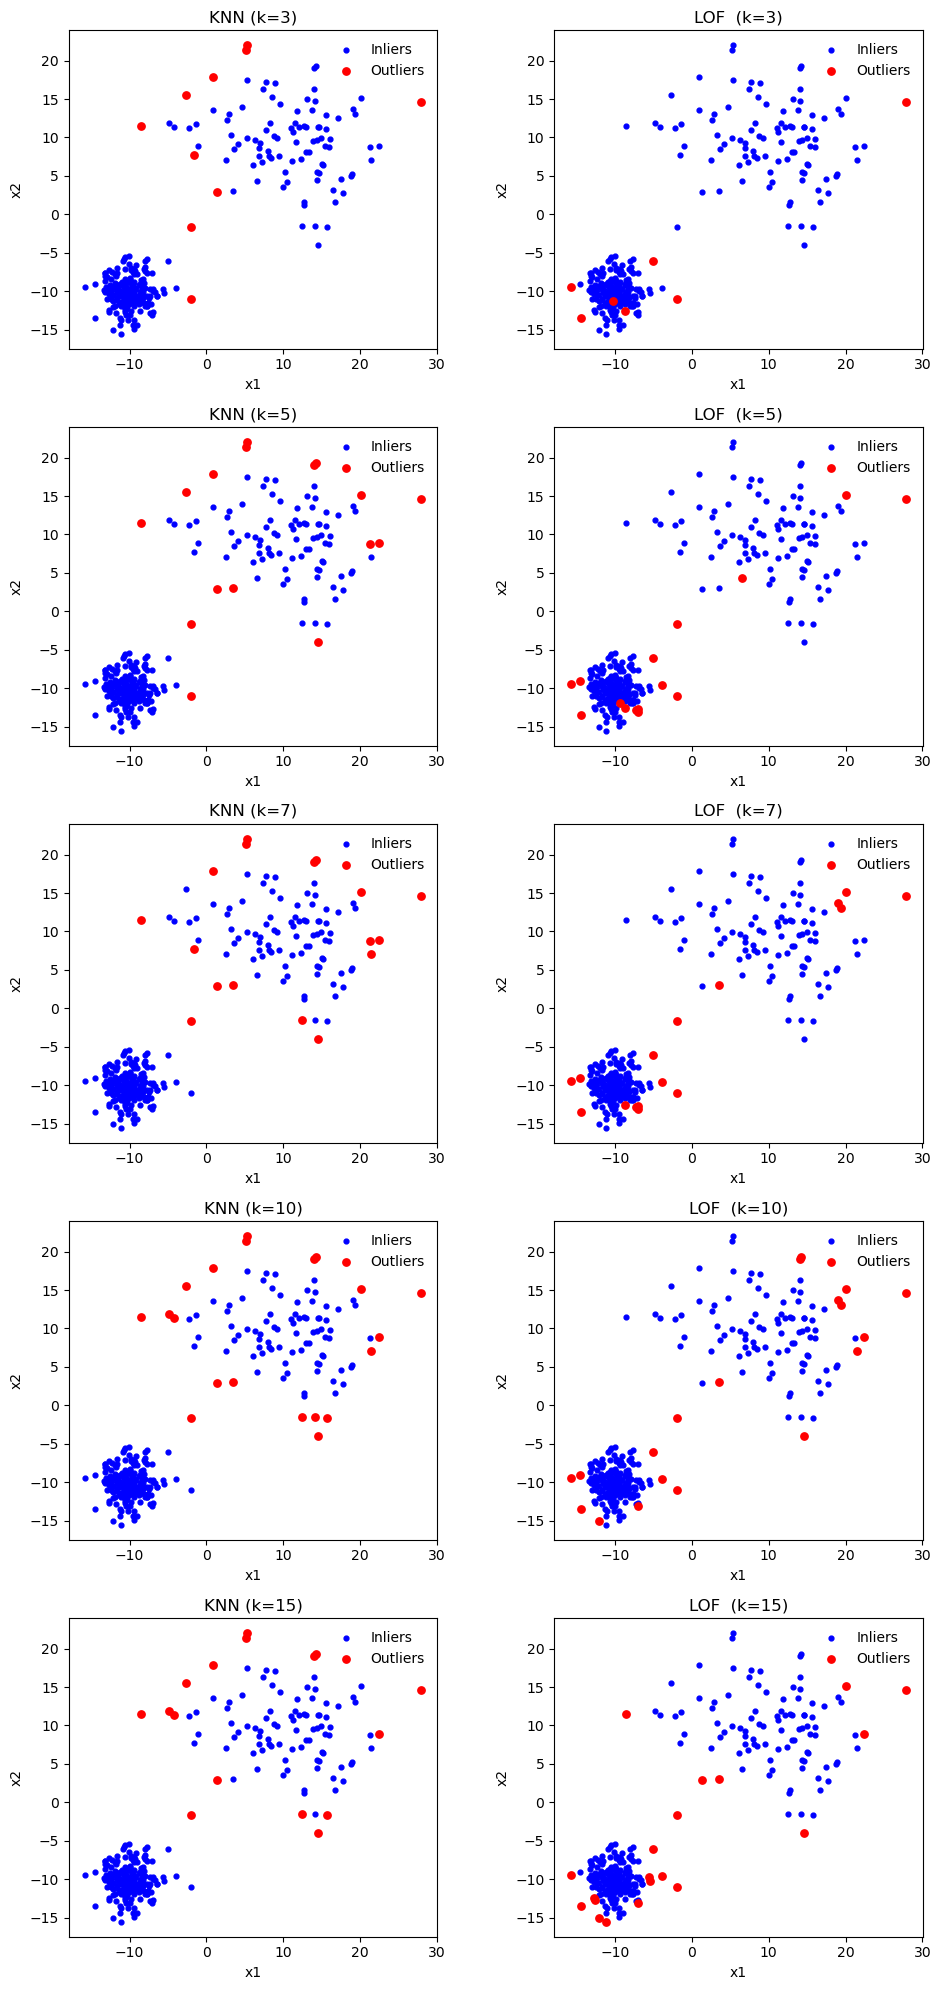

k=3 | KNN outliers:  10 | LOF outliers:   7
k=5 | KNN outliers:  16 | LOF outliers:  15
k=7 | KNN outliers:  17 | LOF outliers:  16
k=10 | KNN outliers:  20 | LOF outliers:  19
k=15 | KNN outliers:  16 | LOF outliers:  20


In [ ]:
X, _ = make_blobs(
    n_samples=[200, 100],
    centers=[(-10, -10), (10, 10)],
    cluster_std=[2, 6],
    n_features=2,
    random_state=28,
    return_centers=False
)

contamination = 0.07
k_list = [3, 5, 7, 10, 15]

fig, axes = plt.subplots(nrows=len(k_list), ncols=2, figsize=(10, 4*len(k_list)))
if len(k_list) == 1:
    axes = np.array([axes])

for i, k in enumerate(k_list):
    y_knn, y_lof = fit_predict_models(X, k, contamination)
    plot_predictions(X, y_knn, axes[i, 0], f"KNN (k={k})")
    plot_predictions(X, y_lof, axes[i, 1], f"LOF  (k={k})")

plt.tight_layout()
plt.show()

for k in k_list:
    y_knn, y_lof = fit_predict_models(X, k, contamination)
    print(f"k={k} | KNN outliers: {y_knn.sum():3d} | LOF outliers: {y_lof.sum():3d}")
    
# Conclusion
"""
KNN often flags many points from the sparser (wide-std) cluster as outliers when k grows, because distances inflate in low-density regions.
LOF adapts to local density, so it tends to keep points in the sparse cluster as inliers if theyre consistent with their local neighbors.
"""

# Ex 4 - Cardio Dataset 

In [179]:
k_list = np.arange(30, 241, 10, dtype=np.uint8)
contamination = 176 / 1831.0

data = scipy.io.loadmat("cardio.mat")

X = data["X"]
y = data["y"].ravel().astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=28, stratify=y)
print("Train outliers:", y_train.sum(), "/", y_train.size)
print("Test outliers:",  y_test.sum(),  "/", y_test.size)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

train_scores = []  
test_scores  = []

print(f"Detector: KNN  k values: [30,40,...,120] contamination≈{contamination:.4f}")

for k in k_list:
    model = KNN(n_neighbors=k, contamination=contamination)
    model.fit(X_train)

    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    ba_tr = balanced_accuracy_score(y_train, y_pred_train)
    ba_te = balanced_accuracy_score(y_test,  y_pred_test)
    print(f"k={k:>3} | BA(train)={ba_tr:.4f} | BA(test)={ba_te:.4f}")
    
    train_scores.append(model.decision_scores_.reshape(-1, 1))
    test_scores.append(model.decision_function(X_test).reshape(-1, 1))

S_train = np.hstack(train_scores)
S_test  = np.hstack(test_scores)

S_train_std, S_test_std = standardizer(S_train, S_test)

avg_train = average(S_train_std)
avg_test  = average(S_test_std)

max_train = maximization(S_train_std)
max_test  = maximization(S_test_std)

q = 1.0 - contamination
thr_avg = np.quantile(avg_train, q)
thr_max = np.quantile(max_train, q)

y_avg_pred_tr = (avg_train >= thr_avg).astype(int)
y_avg_pred_te = (avg_test  >= thr_avg).astype(int)

y_max_pred_tr = (max_train >= thr_max).astype(int)
y_max_pred_te = (max_test  >= thr_max).astype(int)

ba_avg_tr = balanced_accuracy_score(y_train, y_avg_pred_tr)
ba_avg_te = balanced_accuracy_score(y_test,  y_avg_pred_te)
ba_max_tr = balanced_accuracy_score(y_train, y_max_pred_tr)
ba_max_te = balanced_accuracy_score(y_test,  y_max_pred_te)

print("\n=== Ensemble Strategies ===")
print(f"Average:      BA(train)={ba_avg_tr:.4f} | BA(test)={ba_avg_te:.4f}")
print(f"Maximization: BA(train)={ba_max_tr:.4f} | BA(test)={ba_max_te:.4f}")

Train outliers: 123 / 1281
Test outliers: 53 / 550
Detector: KNN  k values: [30,40,...,120] contamination≈0.0961
k= 30 | BA(train)=0.6910 | BA(test)=0.7896
k= 40 | BA(train)=0.7036 | BA(test)=0.8050
k= 50 | BA(train)=0.7081 | BA(test)=0.8040
k= 60 | BA(train)=0.7086 | BA(test)=0.8030
k= 70 | BA(train)=0.7167 | BA(test)=0.8050
k= 80 | BA(train)=0.7311 | BA(test)=0.8269
k= 90 | BA(train)=0.7392 | BA(test)=0.8364
k=100 | BA(train)=0.7437 | BA(test)=0.8374
k=110 | BA(train)=0.7392 | BA(test)=0.8364
k=120 | BA(train)=0.7396 | BA(test)=0.8364
k=130 | BA(train)=0.7437 | BA(test)=0.8364
k=140 | BA(train)=0.7486 | BA(test)=0.8458
k=150 | BA(train)=0.7527 | BA(test)=0.8458
k=160 | BA(train)=0.7572 | BA(test)=0.8552
k=170 | BA(train)=0.7572 | BA(test)=0.8657
k=180 | BA(train)=0.7572 | BA(test)=0.8751
k=190 | BA(train)=0.7576 | BA(test)=0.8845
k=200 | BA(train)=0.7625 | BA(test)=0.8940
k=210 | BA(train)=0.7617 | BA(test)=0.8940
k=220 | BA(train)=0.7617 | BA(test)=0.8930
k=230 | BA(train)=0.7576 | 